# <font color=56A5EC>**Comparação de Modelos de Sobrevivência**</font>

## Análise de 7 Modelos de Sobrevivência com Validação Cruzada e Otimização de Hiperparâmetros

Este notebook implementa um pipeline automático de aprendizado de máquina que:
- Carrega datasets de treino/teste preprocessados
- Aplica codificação mista (ordinal + one-hot)
- Executa busca em grid com validação cruzada estratificada (5-fold)
- Treina 7 modelos de sobrevivência
- Computa 5 métricas de avaliação
- Exporta resultados, predições e melhores parâmetros para comparação

## <font color=56A5EC>**Fase 1: Inicialização e Carregamento de Dados**</font>

### <font color=FFB90F>**Instalações**</font>

In [1]:
%pip install scikit-survival --quiet
%pip install xgboost --quiet
%pip install lightgbm --quiet
%pip install --upgrade lifelines --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### <font color=FFB90F>**Importações**</font>

In [2]:
# === Visualização ===
import matplotlib.pyplot as plt
%matplotlib inline

# === Manipulação ===
import numpy as np
import pandas as pd
import json
import warnings
from pathlib import Path
from datetime import datetime
from IPython.display import display

warnings.filterwarnings("ignore")

# === Sklearn ===
from sklearn import set_config
from sklearn.base import BaseEstimator, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import KFold

set_config(display="text")

# === Scikit-survival ===
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import (
    concordance_index_censored,
    concordance_index_ipcw,
    integrated_brier_score,
    cumulative_dynamic_auc
)

# === XGBoost ===
import xgboost as xgb

# === LightGBM ===
import lightgbm as lgb

print("✓ Imports loaded successfully")


✓ Imports loaded successfully


### <font color=FFB90F>**Carregamento de Dados e Metadados**</font>

In [3]:
# === Paths ===
BASE_DIR = Path("../data/processed")
RESULTS_DIR = Path("./results")
PARAMS_DIR = RESULTS_DIR / "params"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
PREDS_DIR = RESULTS_DIR / "predictions"

for d in [RESULTS_DIR, PARAMS_DIR, FIGURES_DIR, METRICS_DIR, PREDS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [4]:
# === Carregamento de Dados ===
# Load metadata
metadata_path = BASE_DIR / "dataset_metadata_2025.json"
with open(metadata_path, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# Load train and test datasets
df_train = pd.read_csv(BASE_DIR / "train_data_2025.csv")
df_test = pd.read_csv(BASE_DIR / "test_data_2025.csv")

print(f"✓ Train data loaded: {df_train.shape}")
print(f"✓ Test data loaded: {df_test.shape}")
print(f"✓ Metadata loaded with {len(metadata['predictor_columns'])} predictors")

# === Preparar dados para modelagem ===
# Extrair colunas de interesse
predictor_cols = metadata["predictor_columns"]
target_cols = metadata["target_columns"]

X_train = df_train[predictor_cols].copy()
X_test = df_test[predictor_cols].copy()

y_train_time = df_train["time"].astype(float).values
y_train_event = df_train["event"].astype(bool).values

y_test_time = df_test["time"].astype(float).values
y_test_event = df_test["event"].astype(bool).values

# Correct survival targets
y_train_surv = Surv.from_arrays(event=y_train_event, time=y_train_time)
y_test_surv = Surv.from_arrays(event=y_test_event, time=y_test_time)

print("✓ Survival targets created")
print("Train events:", y_train_event.sum(), "/", len(y_train_event))
print("Test events:", y_test_event.sum(), "/", len(y_test_event))


✓ Train data loaded: (26131, 17)
✓ Test data loaded: (6533, 17)
✓ Metadata loaded with 15 predictors
✓ Survival targets created
Train events: 14512 / 26131
Test events: 3628 / 6533


## <font color=56A5EC>**Fase 2: Pré-processamento e Pipeline de Codificação**</font>

<font color=#888B90>Preparação de colunas, transformação e codificação para alimentar os modelos da Fase 3.</font>

In [5]:
# === Metadata-driven columns ===
predictor_cols = metadata["predictor_columns"]
target_cols = metadata["target_columns"]

# Numeric columns from metadata or inferred
numeric_cols = metadata.get(
    "numeric_columns",
    [c for c in predictor_cols if pd.api.types.is_numeric_dtype(df_train[c])]
)

# Explicit categorical split
ordinal_cols = ["ECGRUP"] if "ECGRUP" in predictor_cols else []
onehot_cols = [c for c in ["TOPO", "MORFO_CAT"] if c in predictor_cols]

# Extra categoricals from metadata
extra_cats = [
    c for c in metadata.get("categorical_columns", [])
    if c not in ordinal_cols and c not in onehot_cols
]
onehot_cols = onehot_cols + [c for c in extra_cats if c not in onehot_cols]

# Remove categoricals from numeric list if needed
numeric_cols = [c for c in numeric_cols if c not in ordinal_cols + onehot_cols]

print("Predictors:", predictor_cols)
print("Numeric:", numeric_cols)
print("Ordinal:", ordinal_cols)
print("One-hot:", onehot_cols)

Predictors: ['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CATEATEND', 'DIAGPREV', 'TOPO', 'ECGRUP', 'ANODIAG', 'HABILIT', 'nDRS', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT', 'MORFO_CAT']
Numeric: ['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CATEATEND', 'DIAGPREV', 'ANODIAG', 'HABILIT', 'nDRS', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT']
Ordinal: ['ECGRUP']
One-hot: ['TOPO', 'MORFO_CAT']


In [6]:
# === CÉLULA DESATIVADA (duplicada) ===
# Esta célula repetia a definição de colunas da célula anterior.
# Mantida apenas para histórico do notebook.
print("Célula duplicada desativada. Use a célula anterior para definição de colunas.")

Célula duplicada desativada. Use a célula anterior para definição de colunas.


In [7]:
transformers = []

if numeric_cols:
    transformers.append(("num", StandardScaler(), numeric_cols))

if ordinal_cols:
    transformers.append((
        "ord",
        OrdinalEncoder(
            categories=[["I", "II", "III", "IV"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        ordinal_cols
    ))

if onehot_cols:
    transformers.append((
        "cat",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False
        ),
        onehot_cols
    ))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

print("✓ Preprocessor created")

✓ Preprocessor created


## <font color=56A5EC>**Fase 2.1: Funções Auxiliares de Features e Métricas**</font>

<font color=#888B90>Funções utilitárias usadas na fase de modelagem e avaliação rápida.</font>

In [8]:
def get_feature_names_from_preprocessor(preprocessor, numeric_cols, ordinal_cols, onehot_cols):
    feature_names = []

    if numeric_cols:
        feature_names.extend(numeric_cols)

    if ordinal_cols:
        feature_names.extend(ordinal_cols)

    if onehot_cols:
        ohe = preprocessor.named_transformers_["cat"]
        feature_names.extend(ohe.get_feature_names_out(onehot_cols).tolist())

    return feature_names


def ensure_dataframe(X, feature_names=None):
    if isinstance(X, pd.DataFrame):
        return X.copy()

    X_array = np.asarray(X)
    if feature_names is None:
        feature_names = [f"feature_{idx}" for idx in range(X_array.shape[1])]

    return pd.DataFrame(X_array, columns=list(feature_names))


def safe_predict(model, X):
    pred = model.predict(X)
    return np.asarray(pred, dtype=float).reshape(-1)


def get_eval_times(y_reference):
    candidate_times = np.array([12, 24, 36, 48, 60], dtype=float)
    valid_times = candidate_times[
        (candidate_times > y_reference["time"].min()) &
        (candidate_times < y_reference["time"].max())
    ]

    if valid_times.size == 0:
        valid_times = np.array(
            [np.median(y_reference["time"])],
            dtype=float
        )

    return valid_times


def cindex_scorer(estimator, X, y):
    risk_scores = safe_predict(estimator, X)
    return concordance_index_censored(y["event"], y["time"], risk_scores)[0]


def compute_risk_metrics(risk_scores, y_train_ref, y_test_eval):
    metrics = {}

    metrics["C_Index"] = concordance_index_censored(
        y_test_eval["event"],
        y_test_eval["time"],
        risk_scores
    )[0]

    try:
        metrics["C_Index_IPCW"] = concordance_index_ipcw(
            y_train_ref,
            y_test_eval,
            risk_scores
        )[0]
    except Exception:
        metrics["C_Index_IPCW"] = np.nan

    try:
        eval_times = get_eval_times(y_test_eval)
        auc_values, _ = cumulative_dynamic_auc(
            y_train_ref,
            y_test_eval,
            risk_scores,
            eval_times
        )
        metrics["Mean_Time_AUC"] = float(np.nanmean(auc_values))
    except Exception:
        metrics["Mean_Time_AUC"] = np.nan

    return metrics


def evaluate_risk_model(
    model,
    X_train_ref,
    y_train_ref,
    X_test_eval,
    y_test_eval,
    model_name,
    model_type="risk_score"
):
    metrics = compute_risk_metrics(
        safe_predict(model, X_test_eval),
        y_train_ref,
        y_test_eval
    )
    metrics["IBS"] = np.nan
    metrics["Model_Type"] = model_type

    risk_scores = safe_predict(model, X_test_eval)

    preds_df = pd.DataFrame({
        "sample_index": np.arange(len(y_test_eval)),
        "actual_time": y_test_eval["time"],
        "actual_event": y_test_eval["event"].astype(int),
        "Model_Name": model_name,
        "Model_Type": model_type,
        "risk_score": risk_scores,
        "predicted_time": np.nan
    })

    return metrics, preds_df


def evaluate_time_regression_model(
    model,
    X_train_ref,
    y_train_ref,
    X_test_eval,
    y_test_eval,
    model_name,
    model_type="aft_predicted_time"
):
    predicted_time = safe_predict(model, X_test_eval)
    risk_scores = -predicted_time

    metrics = compute_risk_metrics(risk_scores, y_train_ref, y_test_eval)
    metrics["IBS"] = np.nan
    metrics["Model_Type"] = model_type

    preds_df = pd.DataFrame({
        "sample_index": np.arange(len(y_test_eval)),
        "actual_time": y_test_eval["time"],
        "actual_event": y_test_eval["event"].astype(int),
        "Model_Name": model_name,
        "Model_Type": model_type,
        "risk_score": risk_scores,
        "predicted_time": predicted_time
    })

    return metrics, preds_df


def evaluate_survival_function_model(
    model,
    X_train_ref,
    y_train_ref,
    X_test_eval,
    y_test_eval,
    model_name,
    model_type="survival_function"
):
    metrics = compute_risk_metrics(
        safe_predict(model, X_test_eval),
        y_train_ref,
        y_test_eval
    )

    risk_scores = safe_predict(model, X_test_eval)
    eval_times = get_eval_times(y_test_eval)

    try:
        surv_fns = model.predict_survival_function(X_test_eval)
        surv_probs = np.row_stack(
            [[fn(t) for t in eval_times] for fn in surv_fns]
        )

        if eval_times.size >= 2:
            metrics["IBS"] = integrated_brier_score(
                y_train_ref,
                y_test_eval,
                surv_probs,
                eval_times
            )
        else:
            metrics["IBS"] = np.nan

    except Exception:
        metrics["IBS"] = np.nan

    metrics["Model_Type"] = model_type

    preds_df = pd.DataFrame({
        "sample_index": np.arange(len(y_test_eval)),
        "actual_time": y_test_eval["time"],
        "actual_event": y_test_eval["event"].astype(int),
        "Model_Name": model_name,
        "Model_Type": model_type,
        "risk_score": risk_scores,
        "predicted_time": np.nan
    })

    return metrics, preds_df


def prepare_breslow_targets(times, events):
    order = np.argsort(-times, kind="mergesort")
    times_sorted = np.asarray(times, dtype=float)[order]
    events_sorted = np.asarray(events, dtype=float)[order]

    _, starts = np.unique(times_sorted, return_index=True)
    starts = np.sort(starts)
    ends = np.r_[starts[1:] - 1, len(times_sorted) - 1]

    group_event_counts = np.array(
        [events_sorted[start:end + 1].sum() for start, end in zip(starts, ends)],
        dtype=float
    )

    return order, times_sorted, events_sorted, starts, ends, group_event_counts


def cox_negative_gradient_hessian(preds, signed_time_labels):
    signed_time_labels = np.asarray(signed_time_labels, dtype=float)
    times = np.abs(signed_time_labels)
    events = (signed_time_labels > 0).astype(float)

    order, _, events_sorted, _, ends, group_event_counts = prepare_breslow_targets(times, events)

    preds_sorted = np.asarray(preds, dtype=float)[order]
    shifted_preds = preds_sorted - np.max(preds_sorted)
    exp_preds = np.exp(shifted_preds)
    cumulative_risk = np.cumsum(exp_preds)
    denominators = np.clip(cumulative_risk[ends], 1e-12, None)

    group_ratio = group_event_counts / denominators
    group_ratio_sq = group_event_counts / np.square(denominators)

    contribution = np.zeros_like(preds_sorted)
    contribution_sq = np.zeros_like(preds_sorted)
    contribution[ends] = group_ratio
    contribution_sq[ends] = group_ratio_sq

    suffix_sum = np.cumsum(contribution[::-1])[::-1]
    suffix_sum_sq = np.cumsum(contribution_sq[::-1])[::-1]

    grad_sorted = -events_sorted + exp_preds * suffix_sum
    hess_sorted = exp_preds * suffix_sum - np.square(exp_preds) * suffix_sum_sq
    hess_sorted = np.clip(hess_sorted, 1e-8, None)

    grad = np.empty_like(grad_sorted)
    hess = np.empty_like(hess_sorted)
    grad[order] = grad_sorted
    hess[order] = hess_sorted

    return grad, hess


def cox_negative_partial_log_likelihood(preds, signed_time_labels):
    signed_time_labels = np.asarray(signed_time_labels, dtype=float)
    times = np.abs(signed_time_labels)
    events = (signed_time_labels > 0).astype(float)

    order, _, events_sorted, starts, ends, group_event_counts = prepare_breslow_targets(times, events)

    preds_sorted = np.asarray(preds, dtype=float)[order]
    shifted_preds = preds_sorted - np.max(preds_sorted)
    exp_preds = np.exp(shifted_preds)
    cumulative_risk = np.cumsum(exp_preds)
    denominators = np.clip(cumulative_risk[ends], 1e-12, None)

    event_prediction_sum = np.array(
        [
            preds_sorted[start:end + 1][events_sorted[start:end + 1].astype(bool)].sum()
            for start, end in zip(starts, ends)
        ],
        dtype=float
    )

    loss = np.sum(group_event_counts * np.log(denominators) - event_prediction_sum)
    return float(loss)


def xgb_gain_importance(booster, feature_names):
    importance_map = booster.get_score(importance_type="gain")
    return np.array([importance_map.get(name, 0.0) for name in feature_names], dtype=float)


class XGBoostCoxWrapper(BaseEstimator):
    def __init__(self, params=None, num_boost_round=150):
        self.params = {} if params is None else params
        self.num_boost_round = num_boost_round

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()

        signed_time = np.where(y["event"], y["time"], -y["time"]).astype(float)

        train_matrix = xgb.DMatrix(
            X_df,
            label=signed_time,
            feature_names=self.feature_names_in_.tolist()
        )

        xgb_params = {
            "objective": "survival:cox",
            "eval_metric": "cox-nloglik",
            "learning_rate": 0.05,
            "max_depth": 4,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "min_child_weight": 1.0,
            "tree_method": "hist",
            "verbosity": 0,
            "seed": 42,
        }
        xgb_params.update(self.params)

        self.model_ = xgb.train(
            params=xgb_params,
            dtrain=train_matrix,
            num_boost_round=self.num_boost_round,
            verbose_eval=False
        )

        self.feature_importances_ = xgb_gain_importance(
            self.model_,
            self.feature_names_in_.tolist()
        )
        self.training_params_ = {**xgb_params, "num_boost_round": self.num_boost_round}
        return self

    def predict(self, X):
        X_df = ensure_dataframe(X, feature_names=self.feature_names_in_)
        test_matrix = xgb.DMatrix(
            X_df,
            feature_names=self.feature_names_in_.tolist()
        )
        return self.model_.predict(test_matrix)


class XGBoostAFTWrapper(BaseEstimator):
    def __init__(self, params=None, num_boost_round=150):
        self.params = {} if params is None else params
        self.num_boost_round = num_boost_round

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()

        lower_bound = np.asarray(y["time"], dtype=float)
        upper_bound = lower_bound.copy()
        upper_bound[~y["event"]] = np.inf

        train_matrix = xgb.DMatrix(
            X_df,
            feature_names=self.feature_names_in_.tolist()
        )
        train_matrix.set_float_info("label_lower_bound", lower_bound)
        train_matrix.set_float_info("label_upper_bound", upper_bound)

        aft_params = {
            "objective": "survival:aft",
            "eval_metric": "aft-nloglik",
            "aft_loss_distribution": "normal",
            "aft_loss_distribution_scale": 1.0,
            "learning_rate": 0.05,
            "max_depth": 4,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "tree_method": "hist",
            "verbosity": 0,
            "seed": 42,
        }
        aft_params.update(self.params)

        self.model_ = xgb.train(
            params=aft_params,
            dtrain=train_matrix,
            num_boost_round=self.num_boost_round,
            verbose_eval=False
        )

        self.feature_importances_ = xgb_gain_importance(
            self.model_,
            self.feature_names_in_.tolist()
        )
        self.training_params_ = {**aft_params, "num_boost_round": self.num_boost_round}
        return self

    def predict(self, X):
        X_df = ensure_dataframe(X, feature_names=self.feature_names_in_)
        test_matrix = xgb.DMatrix(
            X_df,
            feature_names=self.feature_names_in_.tolist()
        )
        predicted_log_time = self.model_.predict(test_matrix)
        return np.exp(np.clip(predicted_log_time, -20, 20))


class LightGBMCoxWrapper(BaseEstimator):
    def __init__(self, params=None, num_boost_round=150):
        self.params = {} if params is None else params
        self.num_boost_round = num_boost_round

    def _objective(self, preds, dataset):
        signed_time = dataset.get_label()
        return cox_negative_gradient_hessian(preds, signed_time)

    def _metric(self, preds, dataset):
        signed_time = dataset.get_label()
        loss_value = cox_negative_partial_log_likelihood(preds, signed_time)
        return "cox_neg_partial_loglik", loss_value, False

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()

        signed_time = np.where(y["event"], y["time"], -y["time"]).astype(float)

        train_set = lgb.Dataset(
            X_df,
            label=signed_time,
            feature_name=self.feature_names_in_.tolist(),
            free_raw_data=False
        )

        lgb_params = {
            "objective": self._objective,
            "metric": "None",
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 5,
            "min_data_in_leaf": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l2": 1.0,
            "verbosity": -1,
            "seed": 42,
        }
        lgb_params.update(self.params)

        self.model_ = lgb.train(
            params=lgb_params,
            train_set=train_set,
            num_boost_round=self.num_boost_round,
            feval=self._metric
        )

        self.feature_importances_ = self.model_.feature_importance(importance_type="gain")
        self.training_params_ = {
            **{k: v for k, v in lgb_params.items() if k != "objective"},
            "objective": "custom_cox_partial_loglik",
            "num_boost_round": self.num_boost_round
        }
        return self

    def predict(self, X):
        X_df = ensure_dataframe(X, feature_names=self.feature_names_in_)
        return self.model_.predict(X_df)


## <font color=56A5EC>**Fase 3: Modelagem (Configuração + Treino Rápido)**</font>

<font color=#888B90>Esta fase concentra definição dos modelos, estratégia de validação e treino inicial para inspeção estrutural.</font>

In [9]:
# === Fase 3.1: Configuração dos modelos por família ===
survival_function_models = {
    "Cox_PH": {
        "name": "Cox_PH",
        "family": "survival_function",
        "estimator": Pipeline([
            ("prep", preprocessor),
            ("model", CoxPHSurvivalAnalysis())
        ]),
        "uses_encoded_features": False,
        "predict_mode": "risk_score",
        "supports_survival_function": True,
        "comparison_group": "principal",
        "params": {}
    },
    "Random_Survival_Forest": {
        "name": "Random_Survival_Forest",
        "family": "survival_function",
        "estimator": Pipeline([
            ("prep", preprocessor),
            ("model", RandomSurvivalForest(
                n_estimators=200,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=19,
                n_jobs=1
            ))
        ]),
        "uses_encoded_features": False,
        "predict_mode": "risk_score",
        "supports_survival_function": True,
        "comparison_group": "principal",
        "params": {}
    },
    "Gradient_Boosting_Survival": {
        "name": "Gradient_Boosting_Survival",
        "family": "survival_function",
        "estimator": Pipeline([
            ("prep", preprocessor),
            ("model", GradientBoostingSurvivalAnalysis(
                learning_rate=0.05,
                n_estimators=100,
                random_state=19
            ))
        ]),
        "uses_encoded_features": False,
        "predict_mode": "risk_score",
        "supports_survival_function": True,
        "comparison_group": "principal",
        "params": {}
    }
}

risk_score_models = {
    "FastSurvivalSVM": {
        "name": "FastSurvivalSVM",
        "family": "risk_score",
        "estimator": FastSurvivalSVM(
            alpha=1.0,
            rank_ratio=1.0,
            fit_intercept=False,
            max_iter=200,
            tol=1e-5,
            random_state=19
        ),
        "uses_encoded_features": True,
        "predict_mode": "risk_score",
        "supports_survival_function": False,
        "comparison_group": "principal",
        "params": {
            "alpha": 1.0,
            "rank_ratio": 1.0,
            "fit_intercept": False,
            "max_iter": 200,
            "tol": 1e-5,
            "random_state": 19
        }
    },
    "XGBoost_Cox": {
        "name": "XGBoost_Cox",
        "family": "risk_score",
        "estimator": XGBoostCoxWrapper(
            params={
                "learning_rate": 0.05,
                "max_depth": 4,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "reg_lambda": 1.0
            },
            num_boost_round=150
        ),
        "uses_encoded_features": True,
        "predict_mode": "risk_score",
        "supports_survival_function": False,
        "comparison_group": "principal",
        "params": {
            "objective": "survival:cox",
            "label_encoding": "positive_time_for_event / negative_time_for_right_censoring",
            "learning_rate": 0.05,
            "max_depth": 4,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "num_boost_round": 150
        }
    },
    "LightGBM_Cox": {
        "name": "LightGBM_Cox",
        "family": "risk_score",
        "estimator": LightGBMCoxWrapper(
            params={
                "learning_rate": 0.05,
                "num_leaves": 31,
                "max_depth": 5,
                "feature_fraction": 0.8,
                "bagging_fraction": 0.8,
                "bagging_freq": 1,
                "lambda_l2": 1.0
            },
            num_boost_round=150
        ),
        "uses_encoded_features": True,
        "predict_mode": "risk_score",
        "supports_survival_function": False,
        "comparison_group": "principal",
        "params": {
            "objective": "custom_cox_partial_loglik",
            "label_encoding": "positive_time_for_event / negative_time_for_right_censoring",
            "tie_handling": "breslow",
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 5,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l2": 1.0,
            "num_boost_round": 150
        }
    }
}

aft_models = {
    "XGBoost_AFT": {
        "name": "XGBoost_AFT",
        "family": "aft",
        "estimator": XGBoostAFTWrapper(
            params={
                "learning_rate": 0.05,
                "max_depth": 4,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "reg_lambda": 1.0,
                "aft_loss_distribution": "normal",
                "aft_loss_distribution_scale": 1.0
            },
            num_boost_round=150
        ),
        "uses_encoded_features": True,
        "predict_mode": "predicted_time",
        "supports_survival_function": False,
        "comparison_group": "principal",
        "params": {
            "objective": "survival:aft",
            "label_encoding": "lower_and_upper_bounds",
            "event_bounds": "lower=time, upper=time",
            "censoring_bounds": "lower=time, upper=+inf",
            "aft_loss_distribution": "normal",
            "aft_loss_distribution_scale": 1.0,
            "learning_rate": 0.05,
            "max_depth": 4,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "num_boost_round": 150
        }
    }
}

auxiliary_baselines = {}

model_registry = {}
for model_group in (
    survival_function_models,
    risk_score_models,
    aft_models,
    auxiliary_baselines
):
    model_registry.update(model_group)

principal_model_names = [
    model_name
    for model_name, config in model_registry.items()
    if config["comparison_group"] == "principal"
]

print("✓ Model registry created")
print("Survival-function models:", ", ".join(survival_function_models.keys()))
print("Risk-score models:", ", ".join(risk_score_models.keys()))
print("AFT models:", ", ".join(aft_models.keys()))


✓ Model registry created
Survival-function models: Cox_PH, Random_Survival_Forest, Gradient_Boosting_Survival
Risk-score models: FastSurvivalSVM, XGBoost_Cox, LightGBM_Cox
AFT models: XGBoost_AFT


In [10]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names_encoded = get_feature_names_from_preprocessor(
    preprocessor,
    numeric_cols,
    ordinal_cols,
    onehot_cols
)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names_encoded,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=feature_names_encoded,
    index=X_test.index
)

X_train_encoded.columns = [str(col).replace(" ", "_") for col in X_train_encoded.columns]
X_test_encoded.columns = [str(col).replace(" ", "_") for col in X_test_encoded.columns]

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)
print("✓ Feature names cleaned for encoded-model backends")


Encoded train shape: (26131, 27)
Encoded test shape: (6533, 27)
✓ Feature names cleaned for encoded-model backends


### <font color=FFB90F>**Notas metodológicas dos modelos complementares**</font>

- `FastSurvivalSVM` foi incluído como modelo linear de sobrevivência que produz **risk score** diretamente a partir das features já codificadas.
- `XGBoost_Cox` foi corrigido para usar a censura corretamente: o treino agora recebe **tempo positivo para evento observado** e **tempo negativo para censura à direita**, em vez de usar apenas `y_train_time`.
- `XGBoost_AFT` deixou de ser provisório: o treino usa **lower/upper bounds** (`time/time` para evento e `time/+inf` para censura), que é a parametrização esperada pelo objetivo AFT.
- `LightGBM_Cox` não é regressão de tempo. Ele agora otimiza uma versão customizada da **negative Cox partial log-likelihood** com empates tratados por **Breslow**, e sua saída é interpretada como **risk score**.


In [11]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=19)

print("✓ CV strategy prepared for future tuning")
print("⚠ Hyperparameter search remains disabled in this notebook; fixed parameters are saved for reproducibility.")


✓ CV strategy prepared for future tuning
⚠ Hyperparameter search remains disabled in this notebook; fixed parameters are saved for reproducibility.


In [12]:
# === Fase 3.4: Treino consolidado dos modelos ===
best_models = {}
best_params_summary = {}

print("=" * 80)
print("TRAINING SURVIVAL MODELS")
print("=" * 80)

for model_name, config in model_registry.items():
    print(f"\n{model_name} [{config['family']}]")

    estimator = clone(config["estimator"])
    X_fit = X_train_encoded if config["uses_encoded_features"] else X_train

    try:
        estimator.fit(X_fit, y_train_surv)
    except Exception as exc:
        raise RuntimeError(f"Training failed for {model_name}: {exc}") from exc

    best_models[model_name] = {
        **{k: v for k, v in config.items() if k != "estimator"},
        "estimator": estimator
    }

    fitted_params = config.get("params", {}).copy()
    if hasattr(estimator, "training_params_"):
        fitted_params = estimator.training_params_

    best_params_summary[model_name] = fitted_params
    print("  ✓ fitted successfully")


TRAINING SURVIVAL MODELS

Cox_PH [survival_function]
  ✓ fitted successfully

Random_Survival_Forest [survival_function]
  ✓ fitted successfully

Gradient_Boosting_Survival [survival_function]
  ✓ fitted successfully

FastSurvivalSVM [risk_score]
  ✓ fitted successfully

XGBoost_Cox [risk_score]
  ✓ fitted successfully

LightGBM_Cox [risk_score]
  ✓ fitted successfully

XGBoost_AFT [aft]
  ✓ fitted successfully


### <font color=FFB90F>**Estratégia de avaliação por tipo de saída**</font>

- Modelos com `predict_survival_function` entram como `survival_function` e recebem `C_Index`, `C_Index_IPCW`, `IBS` e `Mean_Time_AUC`.
- Modelos que retornam apenas **risk score** entram como `risk_score`; nesses casos, `IBS` fica como `NaN` porque não há curva de sobrevivência explícita.
- Para `XGBoost_AFT`, a predição é convertida para **tempo previsto** via `exp(margem_log_tempo)` e o risco é definido como `-predicted_time`, mantendo a comparação no mesmo sentido clínico.


### <font color=FFB90F>**Regra do ranking final**</font>

O `Composite_Score` da comparação principal usa apenas as métricas comuns a todos os survival models comparados: `C_Index`, `C_Index_IPCW` e `Mean_Time_AUC`.  
O `IBS` continua reportado, mas fica fora do ranking principal porque exige `predict_survival_function` e, portanto, não está disponível para todos os modelos de forma estrutural.


In [13]:
metrics_records = []
predictions_frames = []

print("=" * 80)
print("EVALUATION")
print("=" * 80)

for model_name, model_entry in best_models.items():
    estimator = model_entry["estimator"]
    model_type = (
        "aft_predicted_time"
        if model_entry["family"] == "aft"
        else model_entry["family"]
    )

    X_train_ref = X_train_encoded if model_entry["uses_encoded_features"] else X_train
    X_test_eval = X_test_encoded if model_entry["uses_encoded_features"] else X_test

    print(f"\nEvaluating {model_name}...")

    if model_entry["supports_survival_function"]:
        metrics, preds_df = evaluate_survival_function_model(
            estimator,
            X_train_ref,
            y_train_surv,
            X_test_eval,
            y_test_surv,
            model_name,
            model_type=model_type
        )
    elif model_entry["family"] == "aft":
        metrics, preds_df = evaluate_time_regression_model(
            estimator,
            X_train_ref,
            y_train_surv,
            X_test_eval,
            y_test_surv,
            model_name,
            model_type=model_type
        )
    else:
        metrics, preds_df = evaluate_risk_model(
            estimator,
            X_train_ref,
            y_train_surv,
            X_test_eval,
            y_test_surv,
            model_name,
            model_type=model_type
        )

    metrics["Model_Name"] = model_name
    metrics["Supports_Survival_Function"] = model_entry["supports_survival_function"]
    metrics["Predict_Mode"] = model_entry["predict_mode"]
    metrics["Comparison_Group"] = model_entry["comparison_group"]

    metrics_records.append(metrics)
    predictions_frames.append(preds_df)

    print("  C-Index:", round(metrics["C_Index"], 4))
    print(
        "  IPCW C-Index:",
        round(metrics["C_Index_IPCW"], 4) if pd.notna(metrics["C_Index_IPCW"]) else np.nan
    )
    print("  IBS:", round(metrics["IBS"], 4) if pd.notna(metrics["IBS"]) else np.nan)
    print(
        "  Mean Time AUC:",
        round(metrics["Mean_Time_AUC"], 4) if pd.notna(metrics["Mean_Time_AUC"]) else np.nan
    )


EVALUATION

Evaluating Cox_PH...
  C-Index: 0.7062
  IPCW C-Index: 0.7052
  IBS: 0.1876
  Mean Time AUC: 0.7616

Evaluating Random_Survival_Forest...
  C-Index: 0.7456
  IPCW C-Index: 0.7441
  IBS: 0.1693
  Mean Time AUC: 0.8065

Evaluating Gradient_Boosting_Survival...
  C-Index: 0.7261
  IPCW C-Index: 0.7247
  IBS: 0.1787
  Mean Time AUC: 0.7829

Evaluating FastSurvivalSVM...
  C-Index: 0.706
  IPCW C-Index: 0.7048
  IBS: nan
  Mean Time AUC: 0.7608

Evaluating XGBoost_Cox...
  C-Index: 0.7439
  IPCW C-Index: 0.7425
  IBS: nan
  Mean Time AUC: 0.8037

Evaluating LightGBM_Cox...
  C-Index: 0.7473
  IPCW C-Index: 0.7458
  IBS: nan
  Mean Time AUC: 0.808

Evaluating XGBoost_AFT...
  C-Index: 0.6718
  IPCW C-Index: 0.6691
  IBS: nan
  Mean Time AUC: 0.7127


In [14]:
required_metric_columns = [
    "Model_Name",
    "Model_Type",
    "C_Index",
    "C_Index_IPCW",
    "IBS",
    "Mean_Time_AUC",
    "Composite_Score"
]

df_metrics = pd.DataFrame(metrics_records)

common_metric_columns = ["C_Index", "C_Index_IPCW", "Mean_Time_AUC"]
df_metrics["Composite_Score"] = df_metrics[common_metric_columns].mean(axis=1, skipna=True)

ibs_bonus = (1 - df_metrics["IBS"]).where(df_metrics["IBS"].notna())
df_metrics["Composite_Score_With_IBS"] = (
    df_metrics[common_metric_columns + ["IBS"]]
    .assign(IBS=ibs_bonus)
    .mean(axis=1, skipna=True)
)

df_metrics = df_metrics.sort_values(
    ["Comparison_Group", "Composite_Score"],
    ascending=[True, False]
).round(4)

df_metrics_main = (
    df_metrics[df_metrics["Comparison_Group"] == "principal"]
    .sort_values("Composite_Score", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("FINAL METRICS TABLE - PRIMARY SURVIVAL COMPARISON")
print("=" * 80)
display(df_metrics_main[required_metric_columns])

if not auxiliary_baselines:
    print("No auxiliary time-regression baselines were included in the main notebook run.")

df_metrics.to_csv(METRICS_DIR / "evaluation_metrics_2025.csv", index=False)

with open(PARAMS_DIR / "hyperparameters_test_2025.json", "w", encoding="utf-8") as f:
    json.dump(best_params_summary, f, indent=2, ensure_ascii=False)

summary_payload = {
    "generated_at": datetime.now().isoformat(),
    "principal_models": principal_model_names,
    "composite_score_definition": (
        "Average of C_Index, C_Index_IPCW and Mean_Time_AUC. "
        "IBS is reported separately because it is only available when "
        "the model exposes predict_survival_function."
    ),
    "ranking": df_metrics_main[["Model_Name", "Composite_Score"]].to_dict(orient="records")
}

with open(RESULTS_DIR / "model_comparison_summary_2025.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2, ensure_ascii=False)

print("✓ Metrics and parameter summaries saved")


FINAL METRICS TABLE - PRIMARY SURVIVAL COMPARISON


,Model_Name,Model_Type,C_Index,C_Index_IPCW,IBS,Mean_Time_AUC,Composite_Score
0,LightGBM_Cox,risk_score,0.7473,0.7458,NaN,0.8080,0.7671
1,Random_Survival_Forest,survival_function,0.7456,0.7441,0.1693,0.8065,0.7654
2,XGBoost_Cox,risk_score,0.7439,0.7425,NaN,0.8037,0.7634
3,Gradient_Boosting_Survival,survival_function,0.7261,0.7247,0.1787,0.7829,0.7446
4,Cox_PH,survival_function,0.7062,0.7052,0.1876,0.7616,0.7244
5,FastSurvivalSVM,risk_score,0.7060,0.7048,NaN,0.7608,0.7239
6,XGBoost_AFT,aft_predicted_time,0.6718,0.6691,NaN,0.7127,0.6845


No auxiliary time-regression baselines were included in the main notebook run.
✓ Metrics and parameter summaries saved


In [15]:
predictions_long = pd.concat(predictions_frames, ignore_index=True)

metadata_predictions = predictions_long[
    ["sample_index", "actual_time", "actual_event"]
].drop_duplicates()

risk_scores_wide = (
    predictions_long.pivot(index="sample_index", columns="Model_Name", values="risk_score")
    .add_suffix("_risk_score")
    .reset_index()
)

predicted_time_wide = (
    predictions_long.pivot(index="sample_index", columns="Model_Name", values="predicted_time")
    .add_suffix("_predicted_time")
    .reset_index()
)

predictions_merged = (
    metadata_predictions
    .merge(risk_scores_wide, on="sample_index", how="left")
    .merge(predicted_time_wide, on="sample_index", how="left")
    .sort_values("sample_index")
)

predictions_long.to_csv(PREDS_DIR / "test_predictions_long_2025.csv", index=False)
predictions_merged.to_csv(PREDS_DIR / "test_predictions_2025.csv", index=False)

print("✓ Long-format predictions saved")
print("✓ Wide-format predictions saved")
display(predictions_merged.head())


✓ Long-format predictions saved
✓ Wide-format predictions saved


,sample_index,actual_time,actual_event,Cox_PH_risk_score,FastSurvivalSVM_risk_score,Gradient_Boosting_Survival_risk_score,LightGBM_Cox_risk_score,Random_Survival_Forest_risk_score,XGBoost_AFT_risk_score,XGBoost_Cox_risk_score,Cox_PH_predicted_time,FastSurvivalSVM_predicted_time,Gradient_Boosting_Survival_predicted_time,LightGBM_Cox_predicted_time,Random_Survival_Forest_predicted_time,XGBoost_AFT_predicted_time,XGBoost_Cox_predicted_time
0,0,5.0,1,1.130800,0.455351,-0.299544,0.020124,31.468714,-4.851652e+08,1.103647,NaN,NaN,NaN,NaN,NaN,4.851652e+08,NaN
1,1,61.0,0,0.956464,0.387268,-0.564428,-0.592336,25.275898,-4.851652e+08,0.719320,NaN,NaN,NaN,NaN,NaN,4.851652e+08,NaN
2,2,8.0,1,1.962008,0.711642,0.878425,1.237704,92.746208,-5.323504e+04,4.104982,NaN,NaN,NaN,NaN,NaN,5.323504e+04,NaN
3,3,61.0,0,-0.396514,-0.215426,-0.891706,-1.480461,11.349418,-4.851652e+08,0.287169,NaN,NaN,NaN,NaN,NaN,4.851652e+08,NaN
4,4,2.0,1,2.718105,1.091561,1.113035,2.050828,98.555583,-2.421104e+02,6.994994,NaN,NaN,NaN,NaN,NaN,2.421104e+02,NaN


In [16]:
print("=" * 80)
print("PIPELINE FINISHED")
print("=" * 80)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Encoded features:", X_train_encoded.shape[1])

if not df_metrics_main.empty:
    print("\nBest model:", df_metrics_main.loc[0, "Model_Name"])
    print("Best composite score:", round(df_metrics_main.loc[0, "Composite_Score"], 4))

print("\nPrimary comparison models:")
for model_name in principal_model_names:
    print("-", model_name)

print("\nImportant notes:")
print("- The 61-month truncation rule remains unchanged from data preprocessing")
print("- FastSurvivalSVM, XGBoost_Cox and LightGBM_Cox are evaluated as risk-score models")
print("- XGBoost_AFT is evaluated as predicted-time / derived-risk model")
print("- IBS is only available for models with predict_survival_function")

print("\nSaved files:")
print("-", METRICS_DIR / "evaluation_metrics_2025.csv")
print("-", PREDS_DIR / "test_predictions_2025.csv")
print("-", PREDS_DIR / "test_predictions_long_2025.csv")
print("-", PARAMS_DIR / "hyperparameters_test_2025.json")
print("-", RESULTS_DIR / "model_comparison_summary_2025.json")
print("-", FIGURES_DIR / "cindex_ipcw_comparison_2025.png")


PIPELINE FINISHED

Train shape: (26131, 15)
Test shape: (6533, 15)
Encoded features: 27

Best model: LightGBM_Cox
Best composite score: 0.7671

Primary comparison models:
- Cox_PH
- Random_Survival_Forest
- Gradient_Boosting_Survival
- FastSurvivalSVM
- XGBoost_Cox
- LightGBM_Cox
- XGBoost_AFT

Important notes:
- The 61-month truncation rule remains unchanged from data preprocessing
- FastSurvivalSVM, XGBoost_Cox and LightGBM_Cox are evaluated as risk-score models
- XGBoost_AFT is evaluated as predicted-time / derived-risk model
- IBS is only available for models with predict_survival_function

Saved files:
- results\metrics\evaluation_metrics_2025.csv
- results\predictions\test_predictions_2025.csv
- results\predictions\test_predictions_long_2025.csv
- results\params\hyperparameters_test_2025.json
- results\model_comparison_summary_2025.json
- results\figures\cindex_ipcw_comparison_2025.png


In [17]:
# Fase desativada
print("Bloco de exportação desativado. Fluxo ativo: Fase 1 a Fase 3.")

Bloco de exportação desativado. Fluxo ativo: Fase 1 a Fase 3.


In [18]:
# Fase desativada
print("Bloco de visualização final desativado. Fluxo ativo: Fase 1 a Fase 3.")

Bloco de visualização final desativado. Fluxo ativo: Fase 1 a Fase 3.


In [19]:
# Fase desativada
print("Bloco de resumo final desativado. Fluxo ativo: Fase 1 a Fase 3.")

Bloco de resumo final desativado. Fluxo ativo: Fase 1 a Fase 3.


In [20]:
# Fase desativada
print("Bloco de finalização desativado. Fluxo ativo: Fase 1 a Fase 3.")

Bloco de finalização desativado. Fluxo ativo: Fase 1 a Fase 3.


## <font color=888B90>**Fase 4: Desativada neste notebook**</font>

<font color=#888B90>Bloco mantido apenas para referência histórica. O fluxo ativo termina na Fase 3.</font>

In [21]:
# Fase desativada
print("Fase 4 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 4 desativada. Fluxo ativo: Fase 1 a Fase 3.


In [22]:
# Fase desativada
print("Fase 4 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 4 desativada. Fluxo ativo: Fase 1 a Fase 3.


## <font color=888B90>**Fase 5: Desativada neste notebook**</font>

In [23]:
# Fase desativada
print("Fase 5 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 5 desativada. Fluxo ativo: Fase 1 a Fase 3.


## <font color=888B90>**Fase 6: Desativada neste notebook**</font>

In [24]:
# Fase desativada
print("Fase 6 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 6 desativada. Fluxo ativo: Fase 1 a Fase 3.


In [25]:
# Fase desativada
print("Fase 6 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 6 desativada. Fluxo ativo: Fase 1 a Fase 3.


## <font color=888B90>**Fase 7: Desativada neste notebook**</font>

In [26]:
# Fase desativada
print("Fase 7 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 7 desativada. Fluxo ativo: Fase 1 a Fase 3.


## <font color=888B90>**Fase 8: Desativada neste notebook**</font>

In [27]:
# Fase desativada
print("Fase 8 desativada. Fluxo ativo: Fase 1 a Fase 3.")

Fase 8 desativada. Fluxo ativo: Fase 1 a Fase 3.


## <font color=56A5EC>**Fase 4: Resultados Consolidados para o Artigo**</font>

### <font color=FFB90F>**Tabela Comparativa dos Modelos**</font>


In [28]:
article_metrics_table = df_metrics_main.set_index("Model_Name").copy()
display(article_metrics_table[[
    "Model_Type",
    "C_Index",
    "C_Index_IPCW",
    "IBS",
    "Mean_Time_AUC",
    "Composite_Score"
]])


,Model_Type,C_Index,C_Index_IPCW,IBS,Mean_Time_AUC,Composite_Score
Model_Name,,,,,,
LightGBM_Cox,risk_score,0.7473,0.7458,NaN,0.8080,0.7671
Random_Survival_Forest,survival_function,0.7456,0.7441,0.1693,0.8065,0.7654
XGBoost_Cox,risk_score,0.7439,0.7425,NaN,0.8037,0.7634
Gradient_Boosting_Survival,survival_function,0.7261,0.7247,0.1787,0.7829,0.7446
Cox_PH,survival_function,0.7062,0.7052,0.1876,0.7616,0.7244
FastSurvivalSVM,risk_score,0.7060,0.7048,NaN,0.7608,0.7239
XGBoost_AFT,aft_predicted_time,0.6718,0.6691,NaN,0.7127,0.6845


### <font color=FFB90F>**Comparação Gráfica das Métricas**</font>


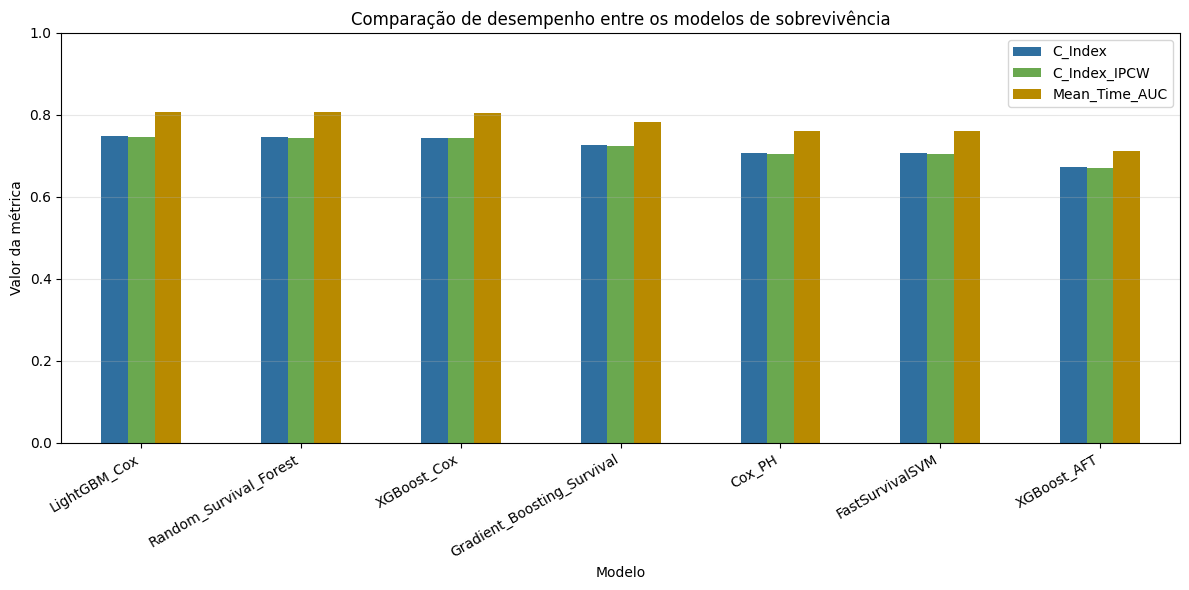

In [29]:
plot_metrics = article_metrics_table[["C_Index", "C_Index_IPCW", "Mean_Time_AUC"]].copy()
ax = plot_metrics.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#2F6F9F", "#6AA84F", "#B88A00"]
)
ax.set_title("Comparação de desempenho entre os modelos de sobrevivência")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor da métrica")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cindex_ipcw_comparison_2025.png", dpi=300, bbox_inches="tight")
plt.show()


### <font color=FFB90F>**Variáveis Mais Influentes no Melhor Modelo Interpretável**</font>


In [30]:
def extract_feature_importance_table(model_name, model_entry):
    model_object = model_entry["estimator"]

    if isinstance(model_object, Pipeline):
        final_model = model_object.named_steps["model"]
        feature_names = X_train_encoded.columns.tolist()
    else:
        final_model = model_object
        feature_names = list(getattr(final_model, "feature_names_in_", X_train_encoded.columns.tolist()))

    if hasattr(final_model, "coef_"):
        importance_values = np.asarray(final_model.coef_).reshape(-1)
        importance_table = pd.DataFrame(
            {
                "Variável": feature_names,
                "Importância": np.abs(importance_values),
                "Sinal": np.where(importance_values >= 0, "Maior risco", "Menor risco"),
                "Valor bruto": importance_values,
            }
        )
        return importance_table.sort_values("Importância", ascending=False)

    if hasattr(final_model, "feature_importances_"):
        importance_values = np.asarray(final_model.feature_importances_).reshape(-1)
        importance_table = pd.DataFrame(
            {
                "Variável": feature_names,
                "Importância": importance_values,
            }
        )
        return importance_table.sort_values("Importância", ascending=False)

    raise AttributeError(f"O modelo {model_name} não expõe coeficientes ou importâncias de variáveis.")


importance_candidates = []
for candidate_name in article_metrics_table.index.tolist():
    try:
        candidate_table = extract_feature_importance_table(candidate_name, best_models[candidate_name])
        importance_candidates.append((candidate_name, candidate_table))
    except Exception:
        continue

if not importance_candidates:
    raise RuntimeError("Nenhum modelo avaliado forneceu uma medida de importância de variáveis utilizável.")

best_interpretable_model_name, best_interpretable_importance = importance_candidates[0]
print(f"Melhor modelo interpretável selecionado: {best_interpretable_model_name}")
display(best_interpretable_importance.head(15).round(4))


Melhor modelo interpretável selecionado: LightGBM_Cox


,Variável,Importância
12,ECGRUP,58194.6049
10,TRATCONS_CAT,12811.5408
2,IDADE,9960.1027
0,INSTITU,7640.4328
6,ANODIAG,3635.0611
4,CATEATEND,3085.4836
11,DIAGTRAT_CAT,2256.9182
8,nDRS,1976.9579
1,ESCOLARI,1845.5748
7,HABILIT,1625.9037
